In [3]:
import glob
import pandas as pd
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.testing.print_coercion_tables import print_new_cast_table
from scipy.stats import gmean
import scipy.stats as stats
import re
import os

from functools import reduce
from matplotlib.colors import to_rgb, to_hex
import colorsys

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [4]:
%run ChartsCommon.ipynb
labels = ['A1', 'A2', 'A3', 'BASE']

./results-12-12/merged/*.txt
                 wf_name     inp_size       ms_1_A1       ms_2_A1  \
0      atacseq_30000.dot  14091675276  1.431198e+10  2.061365e+10   
1      chipseq_15000.dot  41366257414  2.407613e+10  2.480551e+10   
2    methylseq_15000.dot   6761426956  2.943480e+09  5.484017e+09   
3      atacseq_15000.dot   3908761308  2.245540e+09  3.431906e+09   
4                  eager  19075314980  2.721832e+07  2.505490e+07   
..                   ...          ...           ...           ...   
252   methylseq_1000.dot   8885797810  2.436979e+08  4.182758e+08   
253                eager  19132169434  2.739040e+07  2.534256e+07   
254  methylseq_10000.dot  17027257018  5.101491e+09  9.346054e+09   
255        eager_200.dot   8330435694  7.312302e+06  3.635850e+06   
256    chipseq_10000.dot   4807293396  2.704920e+09  4.110610e+09   

          ms_1_A2       ms_2_A2       ms_1_A3       ms_2_A3     ms_1_BASE  \
0    1.432009e+10  1.974438e+10  1.432675e+10  2.861326e+09  1.43

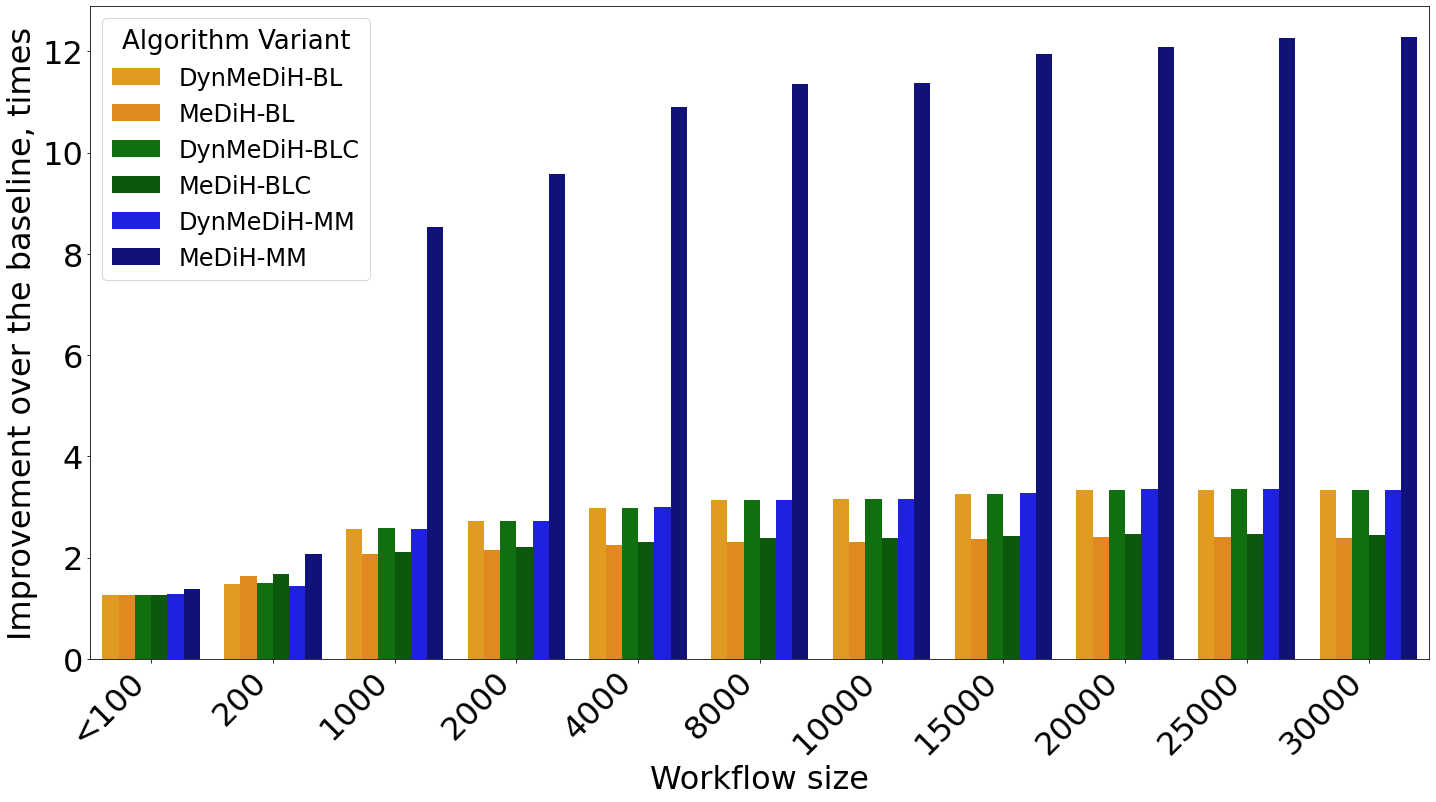

     size                   alg_rel      ratio
0     100    MeDiH-BL - dyn_vs_base   1.257127
1     100   MeDiH-BL - stat_vs_base   1.265508
2     100   MeDiH-BLC - dyn_vs_base   1.251829
3     100  MeDiH-BLC - stat_vs_base   1.265180
4     100    MeDiH-MM - dyn_vs_base   1.270639
..    ...                       ...        ...
61  30000   MeDiH-BL - stat_vs_base   2.386073
62  30000   MeDiH-BLC - dyn_vs_base   3.333133
63  30000  MeDiH-BLC - stat_vs_base   2.437897
64  30000    MeDiH-MM - dyn_vs_base   3.339607
65  30000   MeDiH-MM - stat_vs_base  12.273662

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      2.653830
MeDiH-BL - stat_vs_base     2.104880
MeDiH-BLC - dyn_vs_base     2.659663
MeDiH-BLC - stat_vs_base    2.150332
MeDiH-MM - dyn_vs_base      2.658700
MeDiH-MM - stat_vs_base     7.860461
Name: ratio, dtype: float64


NameError: name 'size_order' is not defined

In [6]:
#/////////////////// NO R/W Cost REDUCTION
path = "./results-12-12/merged/*.txt"
print(path)

patterndevs1 = r'^(BASE|A\d+)-(ndev~mem_8_sp_2_merged)'

dfs=read_dfs(path,patterndevs1, 2)

#print(dfs)

dfsVar1 = [dfs[('A1','ndev~mem_8_sp_2_merged')], dfs[('A2','ndev~mem_8_sp_2_merged')], dfs[('A3','ndev~mem_8_sp_2_merged')], dfs[('BASE','ndev~mem_8_sp_2_merged')]]
#print(dfsVar1)

merged_df_var1 = merge_correct_columns(dfsVar1, labels)
print(merged_df_var1)

plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]


plotDynAndStaticVsBaseNoInset(plot_df, "no_deviations_no_r", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()

allInternals['size_group'] = allInternals['size'].apply(size_category)
filtered = allInternals[allInternals['size_group'] != 'other']
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()


result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-12-12/merged/*.txt


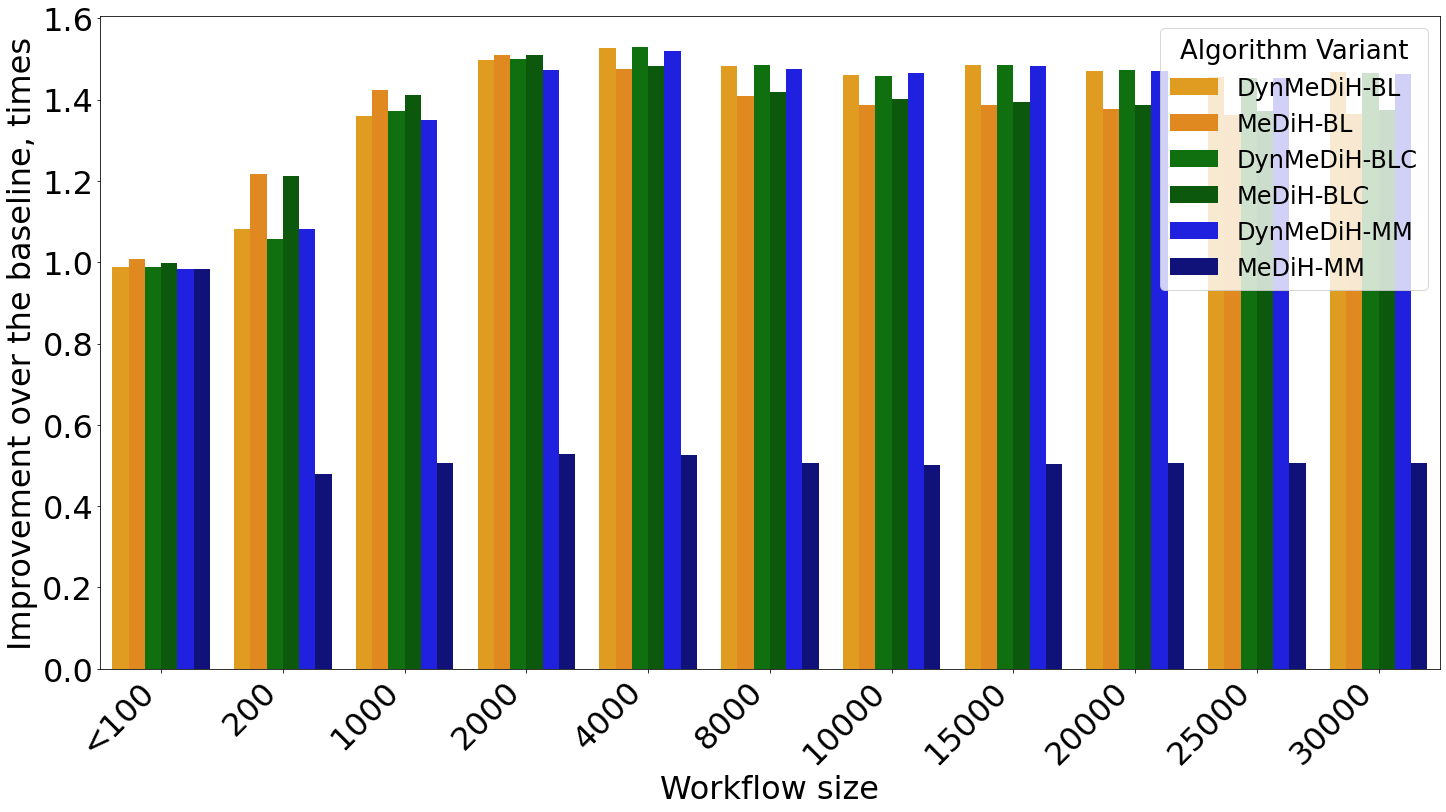

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  0.989449
1     100   MeDiH-BL - stat_vs_base  1.007796
2     100   MeDiH-BLC - dyn_vs_base  0.988193
3     100  MeDiH-BLC - stat_vs_base  0.998701
4     100    MeDiH-MM - dyn_vs_base  0.982955
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  1.365469
62  30000   MeDiH-BLC - dyn_vs_base  1.464905
63  30000  MeDiH-BLC - stat_vs_base  1.375066
64  30000    MeDiH-MM - dyn_vs_base  1.463608
65  30000   MeDiH-MM - stat_vs_base  0.505857

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      1.376461
MeDiH-BL - stat_vs_base     1.349472
MeDiH-BLC - dyn_vs_base     1.374687
MeDiH-BLC - stat_vs_base    1.352694
MeDiH-MM - dyn_vs_base      1.371191
MeDiH-MM - stat_vs_base     0.538345
Name: ratio, dtype: float64


NameError: name 'size_order' is not defined

In [11]:
#///////////////////  R/W Cost REDUCTION 10
path = "./results-12-12/merged/*.txt"
print(path)

patterndevsCost10 = r'^(BASE|A\d+)-(ndev~mem_8_r_10_merged)'

dfsCost10=read_dfs(path,patterndevsCost10, 2)

#print(dfs)

dfsVarCost10 = [dfsCost10[('A1','ndev~mem_8_r_10_merged')], dfsCost10[('A2','ndev~mem_8_r_10_merged')], dfsCost10[('A3','ndev~mem_8_r_10_merged')], dfsCost10[('BASE','ndev~mem_8_r_10_merged')]]
#print(dfsVar1)

merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]


plotDynAndStaticVsBaseNoInset(plot_df, "no_deviations_no_r", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()

allInternals['size_group'] = allInternals['size'].apply(size_category)
filtered = allInternals[allInternals['size_group'] != 'other']
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()


result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-12-12/merged/*.txt
      size            wf_name     inp_size  relation     ratio algorithm
23   30000  atacseq_30000.dot   3908761308  internal  0.693417  MeDiH-BL
116  25000  atacseq_25000.dot  11809629756  internal  0.707207  MeDiH-BL
3    15000  atacseq_15000.dot   3908761308  internal  0.711069  MeDiH-BL
140  20000  atacseq_20000.dot   3908761308  internal  0.711913  MeDiH-BL
104  25000  atacseq_25000.dot   3908761308  internal  0.714620  MeDiH-BL
169  15000  atacseq_15000.dot  11809629756  internal  0.717567  MeDiH-BL
26   30000  atacseq_30000.dot  11187378708  internal  0.718395  MeDiH-BL
22   20000  atacseq_20000.dot  11809629756  internal  0.719015  MeDiH-BL
45   10000  atacseq_10000.dot  11187378708  internal  0.722897  MeDiH-BL
195  10000  atacseq_10000.dot  11809629756  internal  0.724064  MeDiH-BL
103  25000  atacseq_25000.dot  11187378708  internal  0.725417  MeDiH-BL
79   15000  atacseq_15000.dot  11187378708  internal  0.725981  MeDiH-BL
10   30000  atacseq_30

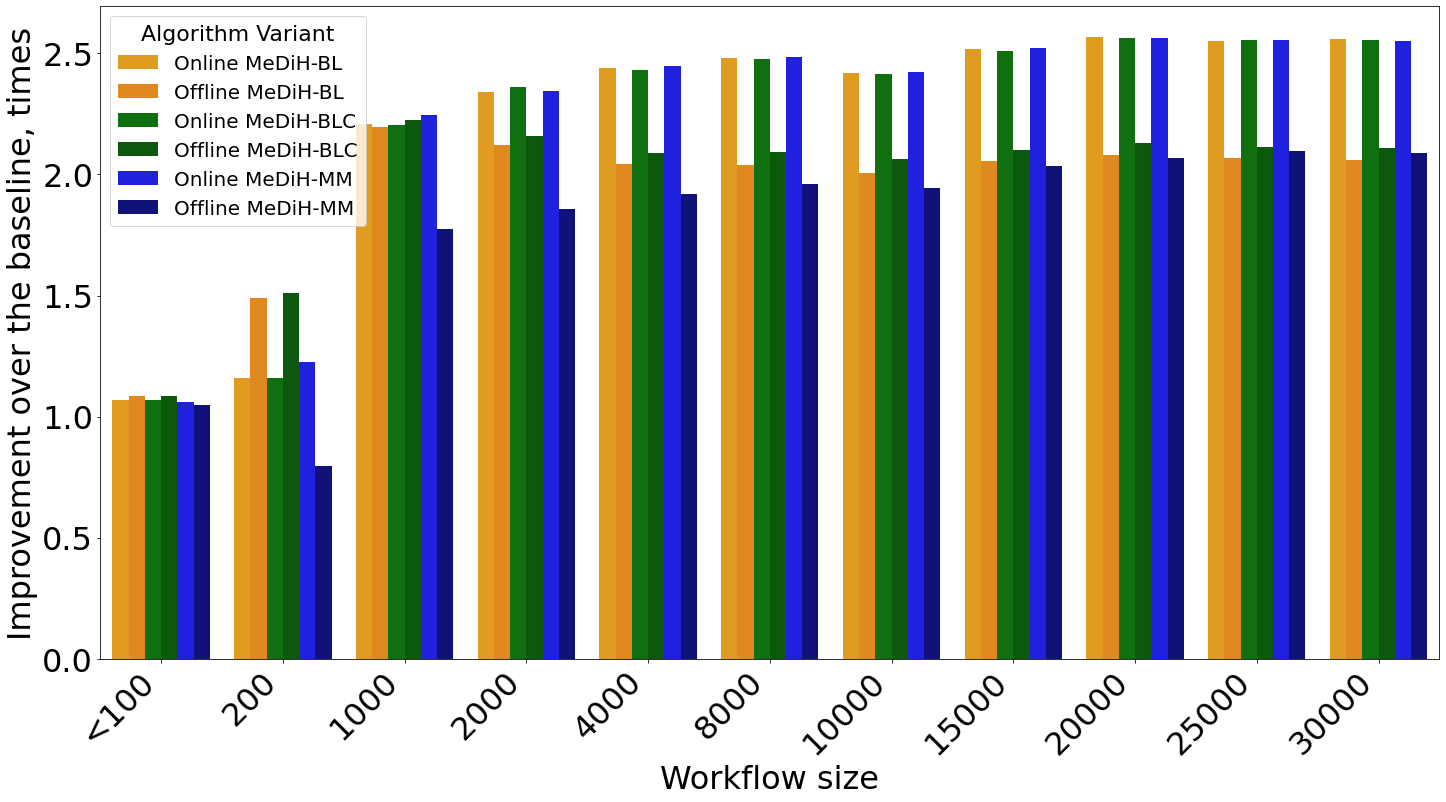

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.068529
1     100   MeDiH-BL - stat_vs_base  1.087131
2     100   MeDiH-BLC - dyn_vs_base  1.067368
3     100  MeDiH-BLC - stat_vs_base  1.086595
4     100    MeDiH-MM - dyn_vs_base  1.059725
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.059773
62  30000   MeDiH-BLC - dyn_vs_base  2.553182
63  30000  MeDiH-BLC - stat_vs_base  2.111103
64  30000    MeDiH-MM - dyn_vs_base  2.551665
65  30000   MeDiH-MM - stat_vs_base  2.090457

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      2.123402
MeDiH-BL - stat_vs_base     1.897587
MeDiH-BLC - dyn_vs_base     2.122480
MeDiH-BLC - stat_vs_base    1.934651
MeDiH-MM - dyn_vs_base      2.136680
MeDiH-MM - stat_vs_base     1.712571
Name: ratio, dtype: float64
!!!!!!!!!!!!!!!!!!!!
    algorithm     ratio
0   MeDiH-BL  0.890503
1  MeDiH-BLC  0.908766
2   MeDiH-MM  0.796944


In [6]:
#///////////////////  R/W Cost REDUCTION 10

size_order = ['small', 'middle', 'large', 'largest']
path = "./results-12-12/merged/*.txt"
print(path)

patterndevs1 = r'^(BASE|A\d+)-(ndev~mem_8_r_10_merged)'

dfs=read_dfs(path,patterndevs1, 2)

#print(dfs)

dfsVar1 = [dfs[('A1','ndev~mem_8_r_10_merged')], dfs[('A2','ndev~mem_8_r_10_merged')], dfs[('A3','ndev~mem_8_r_10_merged')], dfs[('BASE','ndev~mem_8_r_10_merged')]]
#print(dfsVar1)

merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)

plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]


internalRelsSm100Sorted = plot_df[ (plot_df['size']<1000 ) & (plot_df['relation']=='internal')].sort_values('ratio')
#print(internalRelsSorted)

internalRelsSorted = plot_df[ (plot_df['relation']=='internal') & (plot_df['algorithm']=='MeDiH-BL')  ].sort_values('ratio')
print(internalRelsSorted[internalRelsSorted['wf_name'].str.contains('atacseq')])
print(internalRelsSorted[internalRelsSorted['wf_name'].str.contains('methylseq')])
print(internalRelsSorted[internalRelsSorted['wf_name'].str.contains('chipseq')])


plotDynAndStaticVsBaseNoInset(plot_df, "no_deviations_no_r", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()

allInternals['size_group'] = allInternals['size'].apply(size_category)
filtered = allInternals[allInternals['size_group'] != 'other']
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()


result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

#print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
#print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print("!!!!!!!!!!!!!!!!!!!!\n",by_algo)



In [7]:
#print(dfsVar1)

mrgd = merge_correct_columns_keep_all(dfsVar1, labels)
#print(mrgd)
mrgd =mrgd.drop(['algo_nr_A1', 'algo_nr_A2', 'algo_nr_A3', 'algo_nr_BASE'], axis=1)
print(list(mrgd.columns))

['wf_name', 'inp_size', 'avg_spread_dyn_A1', 'cv_proc_load_dyn_A1', 'num_used_procs_dyn_A1', 'idle_to_work_dyn_A1', 'idle_to_work_30s_dyn_A1', 'dur_alg1_A1', 'ms_1_A1', 'avg_spread_stat_A1', 'cv_proc_load_stat_A1', 'num_used_procs_stat_A1', 'idle_to_work_stat_A1', 'idle_to_work_30s_stat_A1', 'ms_perc_A1', 'dur_alg2_A1', 'ms_2_A1', 'avg_spread_dyn_A2', 'cv_proc_load_dyn_A2', 'num_used_procs_dyn_A2', 'idle_to_work_dyn_A2', 'idle_to_work_30s_dyn_A2', 'dur_alg1_A2', 'ms_1_A2', 'avg_spread_stat_A2', 'cv_proc_load_stat_A2', 'num_used_procs_stat_A2', 'idle_to_work_stat_A2', 'idle_to_work_30s_stat_A2', 'ms_perc_A2', 'dur_alg2_A2', 'ms_2_A2', 'avg_spread_dyn_A3', 'cv_proc_load_dyn_A3', 'num_used_procs_dyn_A3', 'idle_to_work_dyn_A3', 'idle_to_work_30s_dyn_A3', 'dur_alg1_A3', 'ms_1_A3', 'avg_spread_stat_A3', 'cv_proc_load_stat_A3', 'num_used_procs_stat_A3', 'idle_to_work_stat_A3', 'idle_to_work_30s_stat_A3', 'ms_perc_A3', 'dur_alg2_A3', 'ms_2_A3', 'avg_spread_dyn_BASE', 'cv_proc_load_dyn_BASE', '

In [61]:
algos = ['A1', 'A2', 'A3', 'BASE']

for algo in algos:
    dyn_col = f'idle_to_work_dyn_{algo}'
    stat_col = f'idle_to_work_stat_{algo}'
    ratio_col = f'idle_to_work_dyn_to_stat_ratio_{algo}'

    mrgd[ratio_col] = np.where(
        mrgd[stat_col] != 0,
        mrgd[dyn_col] / mrgd[stat_col],
        np.nan
    )
    

#print(mrgd, "\n ------------------------------------------------------------- \n")
ratio_cols = [c for c in mrgd.columns if c.startswith('idle_to_work_ratio_')]
ratio_long = (
    mrgd[['wf_name', 'size'] + ratio_cols]
    .melt(
        id_vars=['wf_name', 'size'],
        var_name='algorithm',
        value_name='idle_ratio'
    )
)
ratio_long['algorithm'] = ratio_long['algorithm'].str.replace(
    'idle_to_work_ratio_', '', regex=False)


mrgdOnlyRatios = mrgd[['size'] + mrgd.filter(like='idle_to_work_ratio_').columns.tolist()]

print(mrgdOnlyRatios)




      size  idle_to_work_ratio_A1  idle_to_work_ratio_A2  \
0    30000               0.914848               0.978193   
1    15000               0.951686               1.010236   
2    15000               0.609277               0.610203   
3    15000               0.425344               0.458324   
4      100               0.251317               0.457956   
..     ...                    ...                    ...   
252   1000               0.245395               0.237386   
253    100               0.255483               0.455969   
254  10000               0.145646               0.146345   
255    200               0.952937               1.826828   
256  10000               0.449472               0.526745   

     idle_to_work_ratio_A3  idle_to_work_ratio_BASE  
0                 0.924690                 0.314829  
1                 1.411306                 0.356255  
2               213.974226                 0.481134  
3                 0.375399                 0.144530  
4        

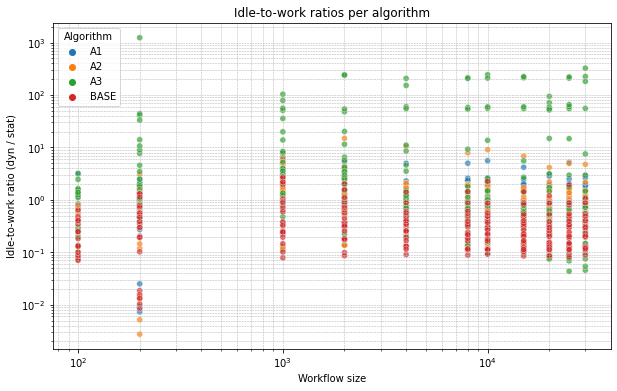

In [62]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=ratio_long,
    x='size',
    y='idle_ratio',
    hue='algorithm',
    palette='tab10',  # or any palette you like
    alpha=0.7
)

plt.xlabel('Workflow size')
plt.ylabel('Idle-to-work ratio (dyn / stat)')
plt.title('Idle-to-work ratios per algorithm')
plt.xscale('log')   # very useful if size spans 100 → 30000
plt.yscale('log')   # optional, handles large outliers
plt.grid(True, which='both', ls='--', lw=0.5)
plt.legend(title='Algorithm')
plt.show()


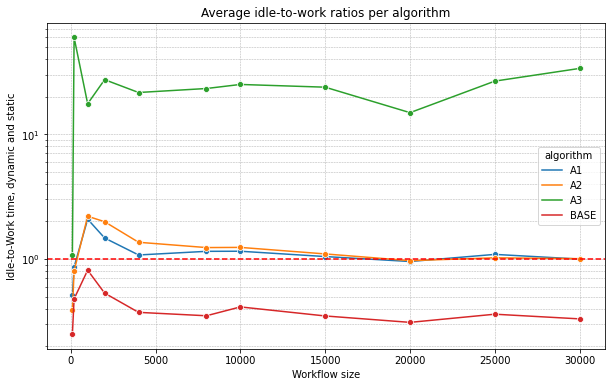

In [67]:
avg_ratio = (
    ratio_long
    .groupby(['size', 'algorithm'], as_index=False)
    .idle_ratio.mean()
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=avg_ratio.sort_values('size'),
    x='size',
    y='idle_ratio',
    hue='algorithm',
    marker='o',
    palette='tab10'
)
baseline_line = plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Equal')    
    
plt.xlabel('Workflow size')
plt.ylabel('Idle-to-Work time, dynamic and static')
plt.title('Ratios of Idle-to-work times per algorithm')
#plt.xscale('log')
plt.yscale('log')  # optional
plt.grid(True, which='both', ls='--', lw=0.5)
plt.show()

In [75]:
algos = ['A1', 'A2', 'A3']

# Prepare long-format table with type (dyn/stat)
records = []

for algo in algos:
    dyn_col = f'idle_to_work_dyn_{algo}'
    stat_col = f'idle_to_work_stat_{algo}'
    
    # group by size and compute means
    grp = mrgd.groupby('size')[[dyn_col, stat_col]].mean().reset_index()
    
    for _, row in grp.iterrows():
        records.append({'size': row['size'], 'algorithm': algo, 'type': 'dyn', 'idle_to_work': row[dyn_col]})
        records.append({'size': row['size'], 'algorithm': algo, 'type': 'stat', 'idle_to_work': row[stat_col]})

avg_long = pd.DataFrame(records)

print(list(avg_long.columns))

['size', 'algorithm', 'type', 'idle_to_work']


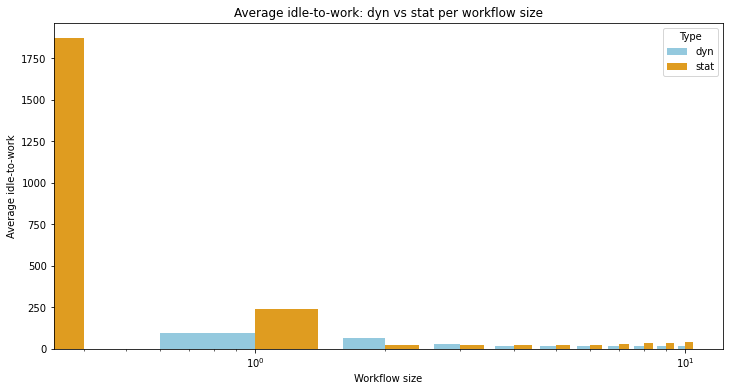

In [76]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=avg_long,
    x='size',
    y='idle_to_work',
    hue='type',       # dyn vs stat
    palette=['skyblue', 'orange'],
    ci=None
)

plt.xlabel('Workflow size')
plt.ylabel('Average idle-to-work')
plt.title('Average idle-to-work: dyn vs stat per workflow size')
plt.xscale('log')   # optional if sizes vary widely
plt.legend(title='Type')
plt.show()

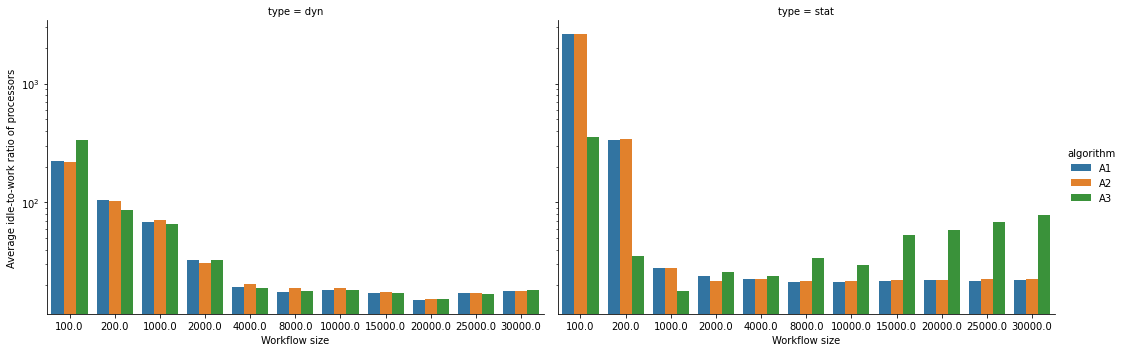

In [83]:
g =sns.catplot(
    data=avg_long,
    x='size',
    y='idle_to_work',
    hue='algorithm',
    col='type',      # dyn/stat in separate columns
    kind='bar',
    height=5,
    aspect=1.5
)

g.set_axis_labels("Workflow size", "Average idle-to-work ratio of processors")
#g.fig.suptitle("Average idle-to-work per workflow size and type", y=1.02)

# Set logarithmic y-axis
g.set(yscale="log")

plt.show()

In [18]:
#print(mrgd.head())

print(mrgd.mean(axis=0).to_string())

algos = ['A1', 'A2', 'A3', 'BASE']

for algo in algos:
    dyn_col = f'idle_to_work_30s_dyn_{algo}'
    stat_col = f'idle_to_work_30s_stat_{algo}'
    ratio_col = f'idle_to_work_30s_dyn_to_stat_ratio_{algo}'

    mrgd[ratio_col] = np.where(
        mrgd[stat_col] != 0,
        mrgd[dyn_col] / mrgd[stat_col],
        np.nan
    )
    

#print(mrgd, "\n ------------------------------------------------------------- \n")
ratio_cols = [c for c in mrgd.columns if c.startswith('idle_to_work_30s_dyn_to_stat_ratio_')]#('idle_to_work_30s_ratio_')]

ratio_long = (
    mrgd[['wf_name', 'size'] + ratio_cols]
    .melt(
        id_vars=['wf_name', 'size'],
        var_name='algorithm',
        value_name='idle_ratio'
    )
)
ratio_long['algorithm'] = ratio_long['algorithm'].str.replace(
    'idle_to_work_30s_ratio_', '', regex=False)


mrgdOnlyRatios = mrgd[['size'] + mrgd.filter(like='idle_to_work_30s_dyn_to_stat_ratio_').columns.tolist()]

print(mrgdOnlyRatios)


inp_size                                   1.802905e+10
avg_spread_dyn_A1                          1.381313e+00
cv_proc_load_dyn_A1                        1.210653e+00
num_used_procs_dyn_A1                      3.236965e+01
idle_to_work_dyn_A1                        4.553251e+01
idle_to_work_30s_dyn_A1                    1.533644e+01
dur_alg1_A1                                5.553357e+01
ms_1_A1                                    7.468624e+08
avg_spread_stat_A1                         1.260843e+00
cv_proc_load_stat_A1                       1.135015e+00
num_used_procs_stat_A1                     3.356031e+01
idle_to_work_stat_A1                       2.246584e+02
idle_to_work_30s_stat_A1                   1.742997e+02
ms_perc_A1                                 8.418249e+08
dur_alg2_A1                                3.713017e+01
ms_2_A1                                    8.418249e+08
avg_spread_dyn_A2                          1.385853e+00
cv_proc_load_dyn_A2                        1.211

/tmp/ipykernel_34877/3359928382.py:3: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  print(mrgd.mean(axis=0).to_string())
